# Обедающие философы: базовый эксперимент

**Цель:** сопоставить классическую сеть Петри и сеть с арбитром для пяти
философов, проверить появление взаимной блокировки и сравнить стохастическую
траекторию с непрерывной аппроксимацией.

In [1]:
using DrWatson
@quickactivate "project"
ENV["GKSwstype"] = "100"
using CSV, DataFrames, Plots, Random, Statistics
include(srcdir("dining_philosophers.jl"))
using .DiningPhilosophers

## Параметры эксперимента
Пять философов используют одинаковые интенсивности переходов.

In [2]:
const N = 5
const TMAX = 50.0
const RATES = default_rates(N; left_rate=2.0, right_rate=1.0, release_rate=1.4)
const IMAGE_DIR = projectdir("..", "image")
const DATA_DIR = datadir("01_dining_philosophers")
mkpath(IMAGE_DIR)
mkpath(DATA_DIR)

"/workspace/labs/lab05/project/data/01_dining_philosophers"

## Построение и стохастическое выполнение сетей
Один seed позволяет повторить каждую базовую траекторию.

In [3]:
classical_net, classical_initial = build_classical_network(N)
arbiter_net, arbiter_initial = build_arbiter_network(N)

classical = simulate_stochastic(classical_net, classical_initial, TMAX;
    rates=RATES, rng=MersenneTwister(202605))
arbiter = simulate_stochastic(arbiter_net, arbiter_initial, TMAX;
    rates=RATES, rng=MersenneTwister(202605))

CSV.write(joinpath(DATA_DIR, "classical_trajectory.csv"), classical.trajectory)
CSV.write(joinpath(DATA_DIR, "arbiter_trajectory.csv"), arbiter.trajectory)

"/workspace/labs/lab05/project/data/01_dining_philosophers/arbiter_trajectory.csv"

## Детерминированная аппроксимация
Непрерывные значения не являются целочисленной маркировкой сети.

In [4]:
ode_classical = simulate_ode(classical_net, classical_initial, 20.0;
    rates=RATES, saveat=0.1)
ode_arbiter = simulate_ode(arbiter_net, arbiter_initial, 20.0;
    rates=RATES, saveat=0.1)
CSV.write(joinpath(DATA_DIR, "classical_ode.csv"), ode_classical)
CSV.write(joinpath(DATA_DIR, "arbiter_ode.csv"), ode_arbiter)

"/workspace/labs/lab05/project/data/01_dining_philosophers/arbiter_ode.csv"

## Сводные показатели
Сопоставляем блокировку, число событий, приёмы пищи и индекс Джейна.

In [5]:
summary = DataFrame(
    variant=["Классическая сеть", "Сеть с арбитром"],
    deadlock=[classical.deadlock, arbiter.deadlock],
    stop_time=[classical.stop_time, arbiter.stop_time],
    events=[classical.events, arbiter.events],
    completed_meals=[sum(classical.meal_counts), sum(arbiter.meal_counts)],
    fairness=[jain_fairness(classical.meal_counts), jain_fairness(arbiter.meal_counts)],
)
CSV.write(joinpath(DATA_DIR, "summary.csv"), summary)

println("=== Обедающие философы: базовый эксперимент ===")
println("Философов: $N, горизонт: $TMAX")
show(summary; allrows=true, allcols=true)
println()
println("Завершённые приёмы пищи, классическая сеть: $(classical.meal_counts)")
println("Завершённые приёмы пищи, сеть с арбитром: $(arbiter.meal_counts)")

=== Обедающие философы: базовый эксперимент ===
Философов: 5, горизонт: 50.0
2×6 DataFrame
 Row │ variant            deadlock  stop_time  events  completed_meals  fairness 
     │ String             Bool      Float64    Int64   Int64            Float64  
─────┼───────────────────────────────────────────────────────────────────────────
   1 │ Классическая сеть      true   0.597319       5                0    0.0
   2 │ Сеть с арбитром       false  48.9047        98               31    0.9109
Завершённые приёмы пищи, классическая сеть: [0, 0, 0, 0, 0]
Завершённые приёмы пищи, сеть с арбитром: [5, 10, 5, 5, 6]


## Эволюция маркировок
Результаты сохраняются в общий каталог изображений лабораторной.

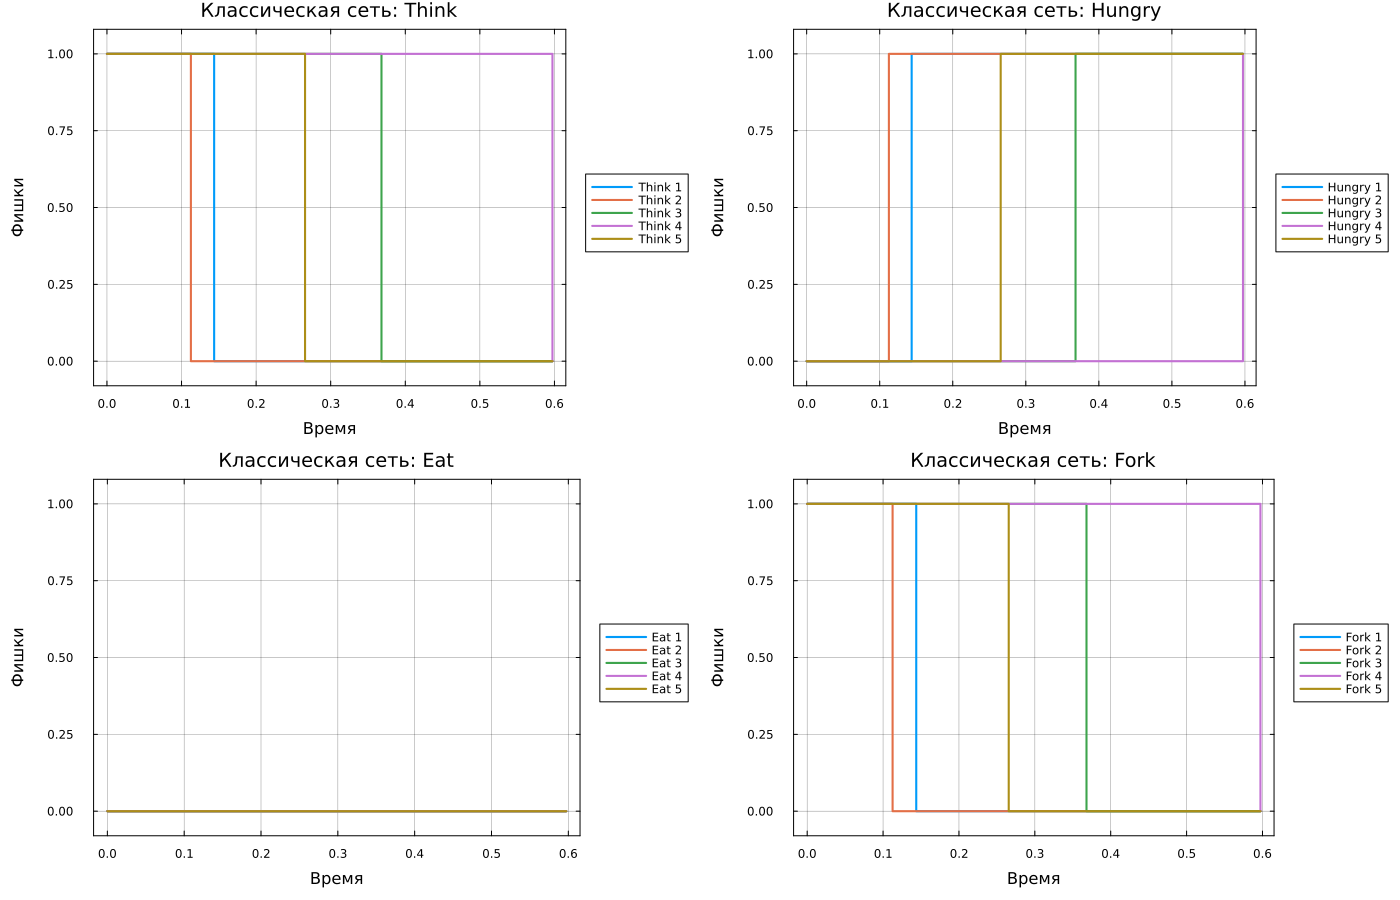

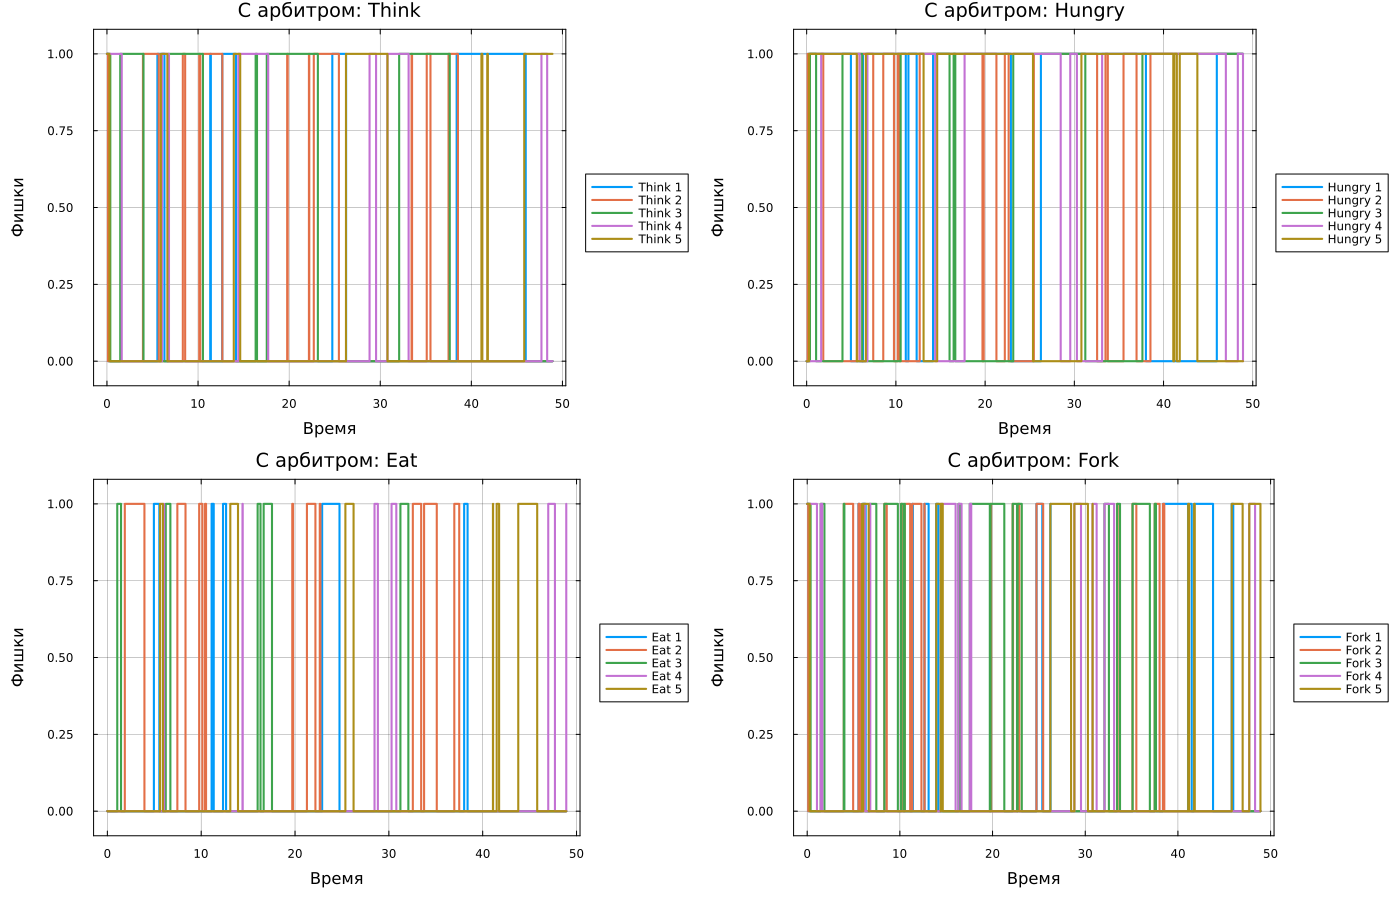

In [6]:
default(fontfamily="DejaVu Sans", linewidth=2.1, framestyle=:box,
    gridalpha=0.22, legendfontsize=8, guidefontsize=11, titlefontsize=13,
    left_margin=7Plots.mm, bottom_margin=5Plots.mm)

function marking_panels(trajectory, N, variant)
    panels = map(("Think", "Hungry", "Eat", "Fork")) do group
        columns = [Symbol("$(group)_$i") for i in 1:N]
        plot(trajectory.time, Matrix(trajectory[:, columns]);
            label=permutedims(["$group $i" for i in 1:N]),
            seriestype=:steppost, xlabel="Время", ylabel="Фишки",
            title="$variant: $group", ylims=(-0.08, 1.08),
            legend=:outerright)
    end
    plot(panels...; layout=(2, 2), size=(1400, 900))
end

p1 = marking_panels(classical.trajectory, N, "Классическая сеть")
savefig(p1, joinpath(IMAGE_DIR, "01-plot.png"))
display(p1)

p2 = marking_panels(arbiter.trajectory, N, "С арбитром")
savefig(p2, joinpath(IMAGE_DIR, "02-plot.png"))
display(p2)

## Сравнение непрерывных решений

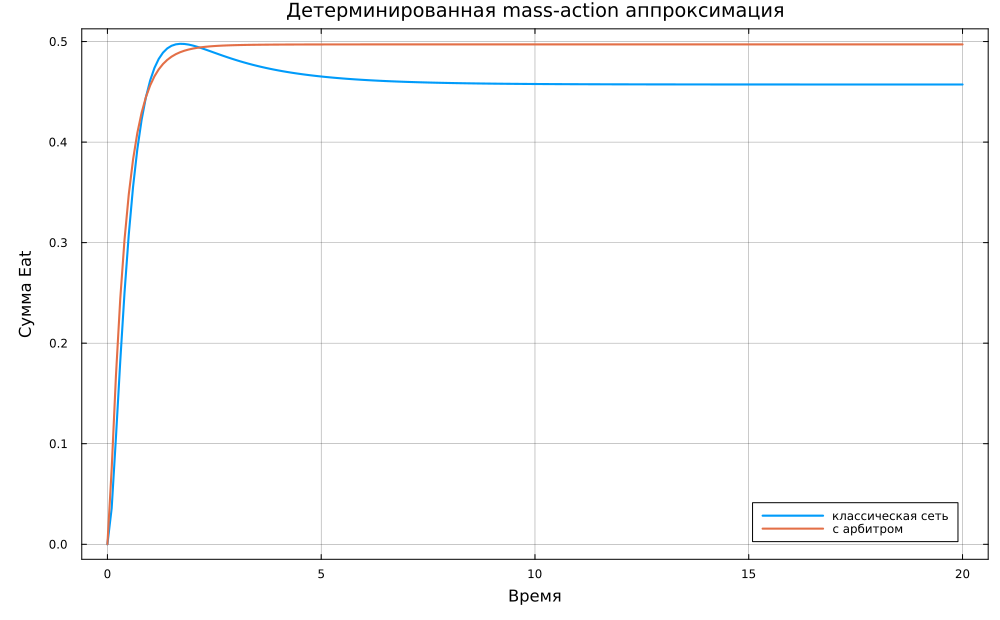

In [7]:
classical_ode_aggregate = aggregate_trajectory(ode_classical, N)
arbiter_ode_aggregate = aggregate_trajectory(ode_arbiter, N)
p4 = plot(classical_ode_aggregate.time, classical_ode_aggregate.Eat;
    label="классическая сеть", xlabel="Время", ylabel="Сумма Eat",
    title="Детерминированная mass-action аппроксимация", size=(1000, 620))
plot!(p4, arbiter_ode_aggregate.time, arbiter_ode_aggregate.Eat;
    label="с арбитром")
savefig(p4, joinpath(IMAGE_DIR, "04-plot.png"))
display(p4)

## Матрица инцидентности

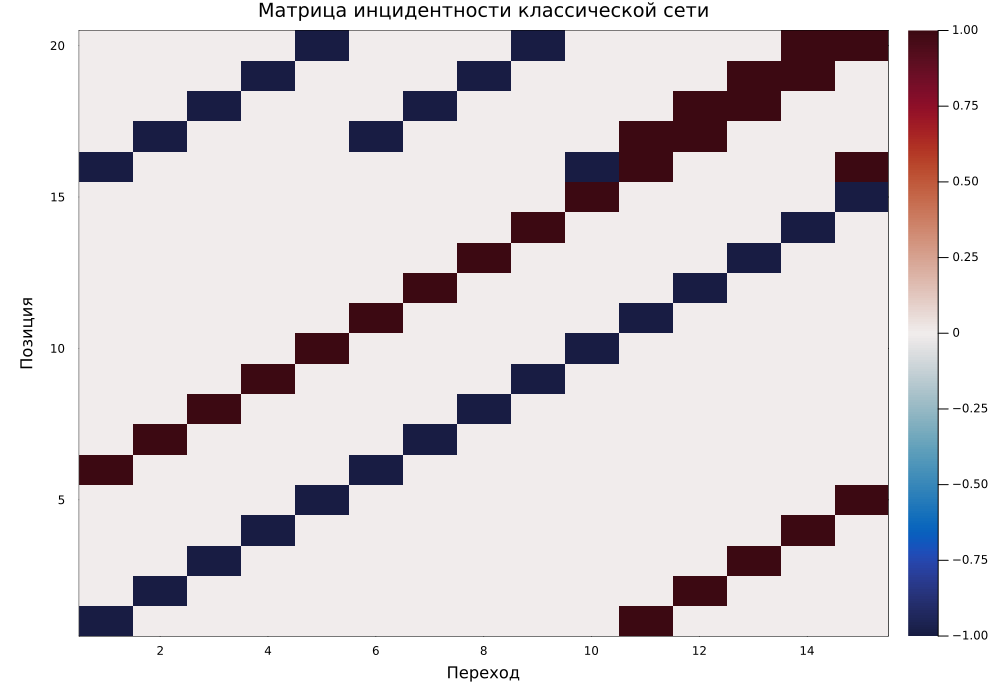

In [8]:
matrix_plot = heatmap(classical_net.output - classical_net.input;
    xlabel="Переход", ylabel="Позиция", title="Матрица инцидентности классической сети",
    color=:balance, size=(1000, 700))
savefig(matrix_plot, joinpath(IMAGE_DIR, "05-plot.png"))
display(matrix_plot)

Классическая сеть заканчивает работу в маркировке, где каждый философ
удерживает одну вилку. Арбитр ограничивает число одновременно начавших захват
ресурсов и тем самым разрывает условие циклического ожидания.